<a href="https://colab.research.google.com/github/Johnogunlola/MRes-AI/blob/MRes/Aircraft_Accident_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import chi2
from scipy.stats import chi2_contingency
import datetime as dt

In [ ]:
!pip install folium
import folium
from folium.plugins import HeatMap

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [ ]:
import warnings
warnings.filterwarnings("ignore")

In [ ]:
df = pd.read_csv('NTSB Accident Report Dataset 2015-2025.csv', encoding='latin1')

In [ ]:
df['HighestInjuryLevel'].fillna('None', inplace=True)
df['AirCraftCategory'].fillna('AIR', inplace=True)
df['WeatherCondition'].fillna('VMC', inplace=True)
df['PurposeOfFlight'].fillna('Public Flight', inplace=True)
df['FAR'].fillna('91' '137' '121', inplace=True)

KeyError: 'AirCraftCategory'

In [ ]:
display(df.columns)

Index(['EventType = Accident (ACC) or Incidence (INC) or Occurrence (OCC)',
       'EventDate', 'City', 'State', 'Country', 'N = Registration No',
       'Has Safety Recommendations (Indicates whether the NTSB report includes formal safety recommendations (TRUE/FALSE)',
       'ReportType', 'HighestInjuryLevel', 'FatalInjuryCount',
       'SeriousInjuryCount', 'MinorInjuryCount', 'ProbableCause', 'Latitude',
       'Longitude', 'Make', 'Model',
       'Aircraft Category  Broad classification of the aircraft type: "AIR" (Airplane), "HELI" (Helicopter), "GLDR" (Glider), "BALN" (Balloon), "UNMANNED" (Unmanned Aircraft System), ',
       'AirportID', 'AirportName',
       'AmateurBuiltAmateur Built  Indicates whether the aircraft was amateur-built or kit-built (TRUE/FALSE).',
       'NumberOfEngines', 'Scheduled', 'PurposeOfFlight',
       'Federal Aviation Regulation FAR  The primary regulation under which the flight was conducted (e.g., 91, 121, 135). 91= General Operating Rules, 121=

In [ ]:
df['TotalInjuries'] = df['FatalInjuryCount'] + df['SeriousInjuryCount'] + df['MinorInjuryCount']

In [ ]:
df['HighRiskEvent'] = df['FatalInjuryCount'].apply(lambda x: 1 if x > 0 else 0)

In [ ]:
df['HighRiskEvent'] = df['FatalInjuryCount'].apply(lambda x: 1 if x > 0 else 0)

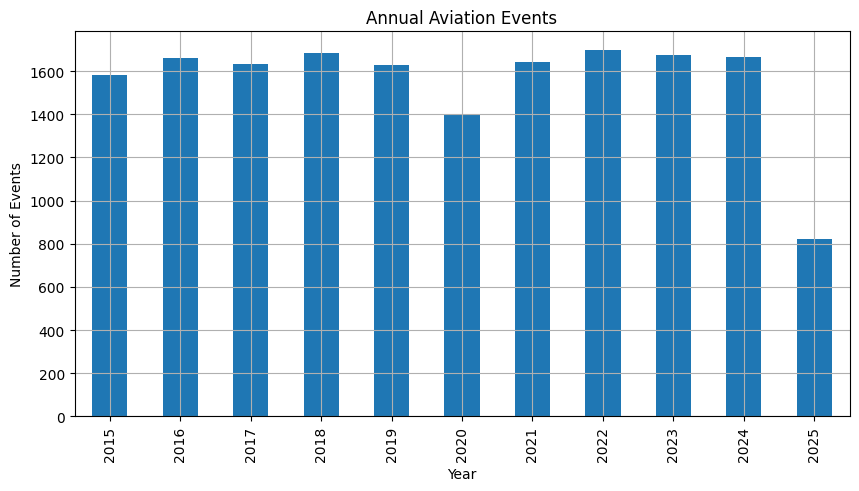

In [ ]:
plt.figure(figsize=(10,5))
df['Year'].value_counts().sort_index().plot(kind='bar')
plt.title('Annual Aviation Events')
plt.xlabel('Year')
plt.ylabel('Number of Events')
plt.grid()
plt.show()

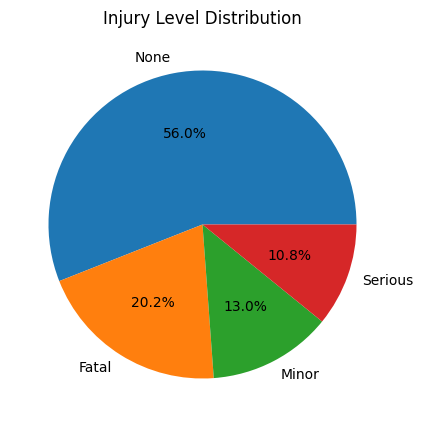

In [ ]:
plt.figure(figsize=(8,5))
df['HighestInjuryLevel'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Injury Level Distribution')
plt.ylabel('')
plt.show()

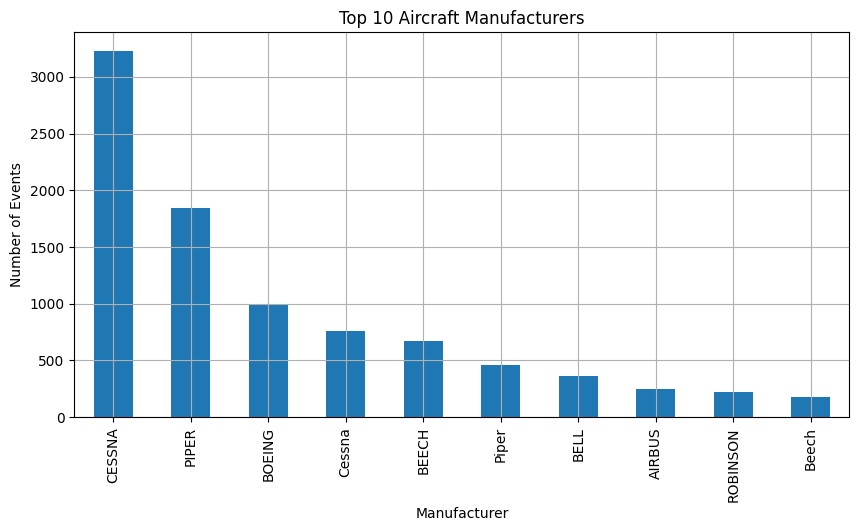

In [ ]:
plt.figure(figsize=(10,5))
df['Make'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Aircraft Manufacturers')
plt.xlabel('Manufacturer')
plt.ylabel('Number of Events')
plt.grid()
plt.show()

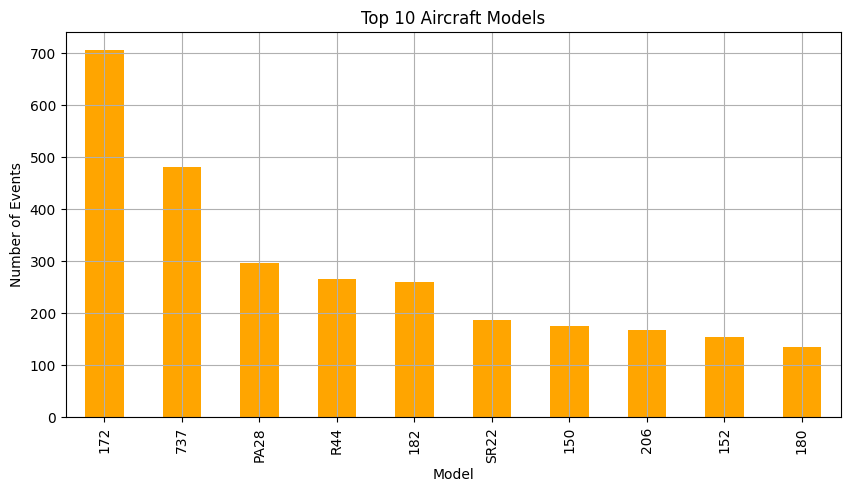

In [ ]:
plt.figure(figsize=(10,5))
df['Model'].value_counts().head(10).plot(kind='bar', color='orange')
plt.title('Top 10 Aircraft Models')
plt.xlabel('Model')
plt.ylabel('Number of Events')
plt.grid()
plt.show()

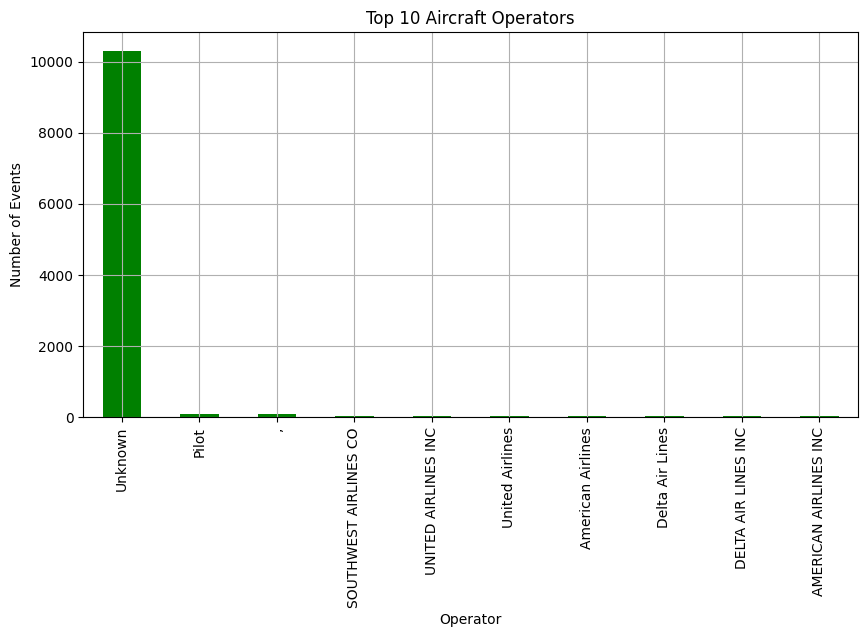

In [ ]:
plt.figure(figsize=(10,5))
df['Operator'].fillna('Unknown').value_counts().head(10).plot(kind='bar', color='green')
plt.title('Top 10 Aircraft Operators')
plt.xlabel('Operator')
plt.ylabel('Number of Events')
plt.grid()
plt.show()

In [ ]:
display(df.columns)

Index(['EventType = Accident (ACC) or Incidence (INC) or Occurrence (OCC)',
       'EventDate', 'City', 'State', 'Country', 'N = Registration No',
       'Has Safety Recommendations (Indicates whether the NTSB report includes formal safety recommendations (TRUE/FALSE)',
       'ReportType', 'HighestInjuryLevel', 'FatalInjuryCount',
       'SeriousInjuryCount', 'MinorInjuryCount', 'ProbableCause', 'Latitude',
       'Longitude', 'Make', 'Model',
       'Aircraft Category  Broad classification of the aircraft type: "AIR" (Airplane), "HELI" (Helicopter), "GLDR" (Glider), "BALN" (Balloon), "UNMANNED" (Unmanned Aircraft System), ',
       'AirportID', 'AirportName',
       'AmateurBuiltAmateur Built  Indicates whether the aircraft was amateur-built or kit-built (TRUE/FALSE).',
       'NumberOfEngines', 'Scheduled', 'PurposeOfFlight',
       'Federal Aviation Regulation FAR  The primary regulation under which the flight was conducted (e.g., 91, 121, 135). 91= General Operating Rules, 121=

In [ ]:
heat_df = df[['Latitude', 'Longitude']].dropna()

m = folium.Map(location=[39.8283, -98.5795], zoom_start=4)
HeatMap(data=heat_df[['Latitude', 'Longitude']].values.tolist(), radius=10).add_to(m)

In [ ]:
display(df.columns)

Index(['EventType = Accident (ACC) or Incidence (INC) or Occurrence (OCC)',
       'EventDate', 'City', 'State', 'Country', 'N = Registration No',
       'Has Safety Recommendations (Indicates whether the NTSB report includes formal safety recommendations (TRUE/FALSE)',
       'ReportType', 'HighestInjuryLevel', 'FatalInjuryCount',
       'SeriousInjuryCount', 'MinorInjuryCount', 'ProbableCause', 'Latitude',
       'Longitude', 'Make', 'Model',
       'Aircraft Category  Broad classification of the aircraft type: "AIR" (Airplane), "HELI" (Helicopter), "GLDR" (Glider), "BALN" (Balloon), "UNMANNED" (Unmanned Aircraft System), ',
       'AirportID', 'AirportName',
       'AmateurBuiltAmateur Built  Indicates whether the aircraft was amateur-built or kit-built (TRUE/FALSE).',
       'NumberOfEngines', 'Scheduled', 'PurposeOfFlight',
       'Federal Aviation Regulation FAR  The primary regulation under which the flight was conducted (e.g., 91, 121, 135). 91= General Operating Rules, 121=

In [ ]:
heat_df = df[['Latitude', 'Longitude']].dropna()

m = folium.Map(location=[39.8283, -98.5795], zoom_start=4)
HeatMap(data=heat_df[['Latitude', 'Longitude']].values.tolist(), radius=10).add_to(m)

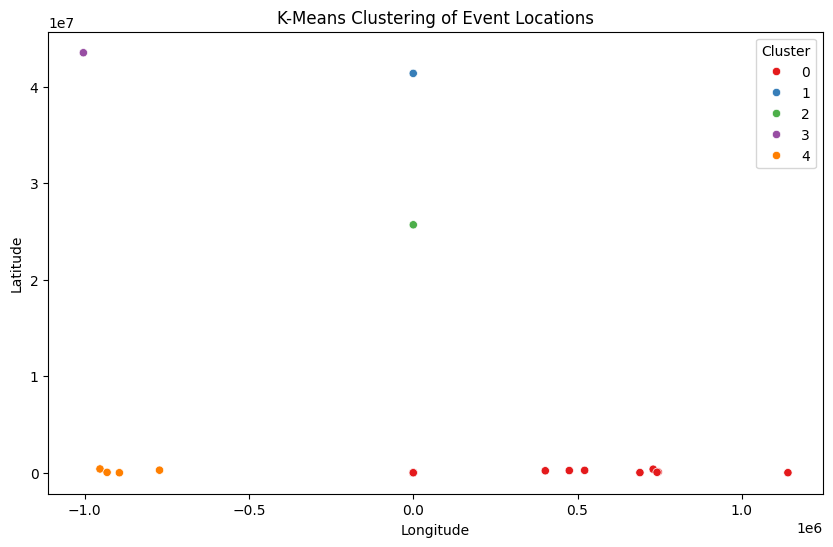

In [ ]:
coords = heat_df[['Latitude', 'Longitude']]
kmeans = KMeans(n_clusters=5)
heat_df['Cluster'] = kmeans.fit_predict(coords)

plt.figure(figsize=(10,6))
sns.scatterplot(data=heat_df, x='Longitude', y='Latitude', hue='Cluster', palette='Set1')
plt.title('K-Means Clustering of Event Locations')
plt.show()

In [ ]:
monthly_trend = df.groupby(pd.Grouper(key='EventDate', freq='M'))['FatalInjuryCount'].sum()

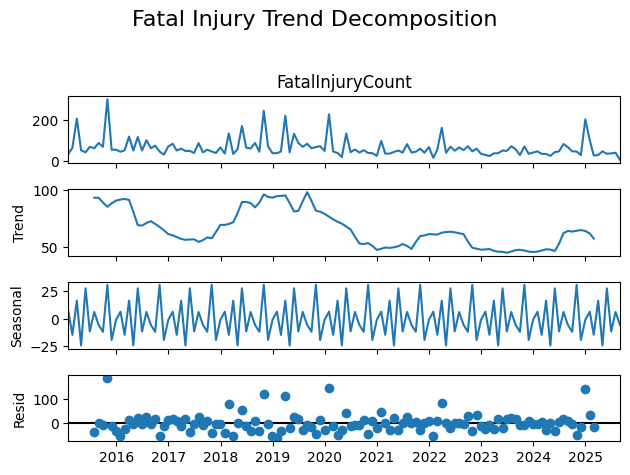

In [ ]:
fig = result.plot()
plt.suptitle('Fatal Injury Trend Decomposition', fontsize=16, x=0.5, y=0.98)  # Adjust position above plots
fig.tight_layout(rect=[0, 0, 1, 0.95])  # Leave space at the top for the suptitle
plt.show()

In [ ]:
contingency = pd.crosstab(df['HighestInjuryLevel'], df['Weather Condition  The meteorological conditions at the time: "VMC" (Visual Meteorological Conditions), "IMC" (Instrument Meteorological Conditions), "UNK" (Unknown)'])
chi2_stat, p_val, dof, expected = chi2_contingency(contingency)

print("Chi-Square Test between Injury Level and Weather Condition:")
print(f"Chi2 = {chi2_stat:.2f}, p-value = {p_val:.4f}")

Chi-Square Test between Injury Level and Weather Condition:
Chi2 = 713.55, p-value = 0.0000


In [ ]:
display(df.columns)

Index(['EventType = Accident (ACC) or Incidence (INC) or Occurrence (OCC)',
       'EventDate', 'City', 'State', 'Country', 'N = Registration No',
       'Has Safety Recommendations (Indicates whether the NTSB report includes formal safety recommendations (TRUE/FALSE)',
       'ReportType', 'HighestInjuryLevel', 'FatalInjuryCount',
       'SeriousInjuryCount', 'MinorInjuryCount', 'ProbableCause', 'Latitude',
       'Longitude', 'Make', 'Model',
       'Aircraft Category  Broad classification of the aircraft type: "AIR" (Airplane), "HELI" (Helicopter), "GLDR" (Glider), "BALN" (Balloon), "UNMANNED" (Unmanned Aircraft System), ',
       'AirportID', 'AirportName',
       'AmateurBuiltAmateur Built  Indicates whether the aircraft was amateur-built or kit-built (TRUE/FALSE).',
       'NumberOfEngines', 'Scheduled', 'PurposeOfFlight',
       'Federal Aviation Regulation FAR  The primary regulation under which the flight was conducted (e.g., 91, 121, 135). 91= General Operating Rules, 121=

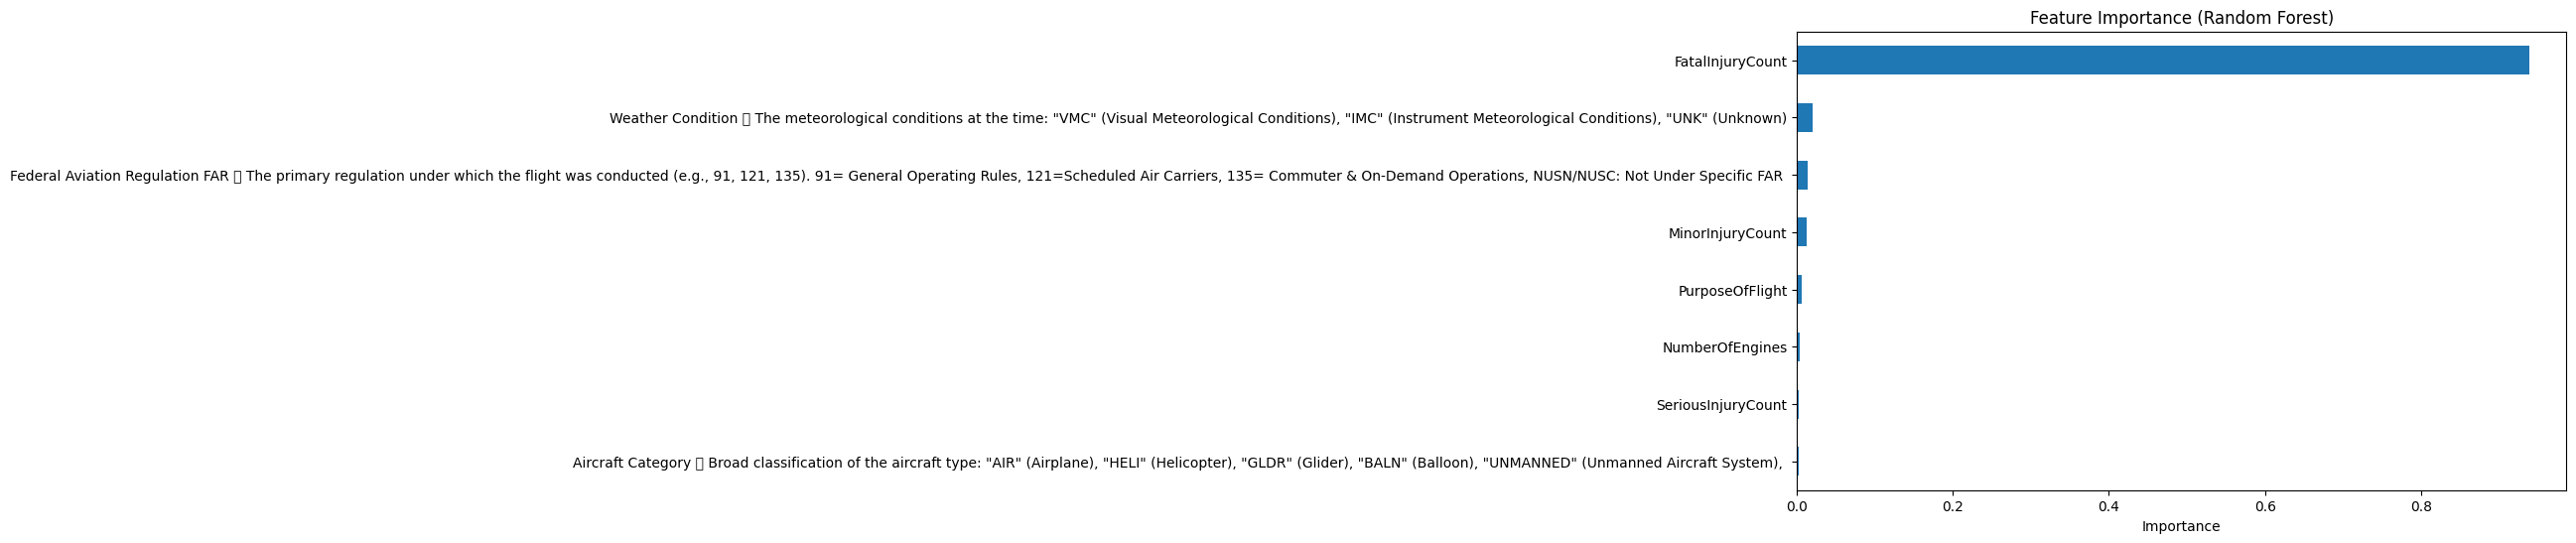

In [ ]:
cat_cols = ['Aircraft Category  Broad classification of the aircraft type: "AIR" (Airplane), "HELI" (Helicopter), "GLDR" (Glider), "BALN" (Balloon), "UNMANNED" (Unmanned Aircraft System), ',
            'Weather Condition  The meteorological conditions at the time: "VMC" (Visual Meteorological Conditions), "IMC" (Instrument Meteorological Conditions), "UNK" (Unknown)',
            'PurposeOfFlight',
            'Federal Aviation Regulation FAR  The primary regulation under which the flight was conducted (e.g., 91, 121, 135). 91= General Operating Rules, 121=Scheduled Air Carriers, 135= Commuter & On-Demand Operations, NUSN/NUSC: Not Under Specific FAR ']
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

# Clean and convert 'NumberOfEngines' to numeric
df['NumberOfEngines'] = df['NumberOfEngines'].astype(str).str.split(',').str[0]
df['NumberOfEngines'] = pd.to_numeric(df['NumberOfEngines'], errors='coerce')
df['NumberOfEngines'].fillna(1, inplace=True) # Fill NaN values, assuming 1 engine is a reasonable default


features = ['FatalInjuryCount', 'SeriousInjuryCount', 'MinorInjuryCount',
            'Aircraft Category  Broad classification of the aircraft type: "AIR" (Airplane), "HELI" (Helicopter), "GLDR" (Glider), "BALN" (Balloon), "UNMANNED" (Unmanned Aircraft System), ',
            'Weather Condition  The meteorological conditions at the time: "VMC" (Visual Meteorological Conditions), "IMC" (Instrument Meteorological Conditions), "UNK" (Unknown)',
            'PurposeOfFlight',
            'Federal Aviation Regulation FAR  The primary regulation under which the flight was conducted (e.g., 91, 121, 135). 91= General Operating Rules, 121=Scheduled Air Carriers, 135= Commuter & On-Demand Operations, NUSN/NUSC: Not Under Specific FAR ',
            'NumberOfEngines']
X = df[features].dropna()
y = df.loc[X.index, 'HighRiskEvent']

model = RandomForestClassifier()
model.fit(X, y)

importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh', figsize=(10,6), title='Feature Importance (Random Forest)')
plt.xlabel('Importance')
plt.show()

In [ ]:
display(df.columns)

Index(['EventType = Accident (ACC) or Incidence (INC) or Occurrence (OCC)',
       'EventDate', 'City', 'State', 'Country', 'N = Registration No',
       'Has Safety Recommendations (Indicates whether the NTSB report includes formal safety recommendations (TRUE/FALSE)',
       'ReportType', 'HighestInjuryLevel', 'FatalInjuryCount',
       'SeriousInjuryCount', 'MinorInjuryCount', 'ProbableCause', 'Latitude',
       'Longitude', 'Make', 'Model',
       'Aircraft Category  Broad classification of the aircraft type: "AIR" (Airplane), "HELI" (Helicopter), "GLDR" (Glider), "BALN" (Balloon), "UNMANNED" (Unmanned Aircraft System), ',
       'AirportID', 'AirportName',
       'AmateurBuiltAmateur Built  Indicates whether the aircraft was amateur-built or kit-built (TRUE/FALSE).',
       'NumberOfEngines', 'Scheduled', 'PurposeOfFlight',
       'Federal Aviation Regulation FAR  The primary regulation under which the flight was conducted (e.g., 91, 121, 135). 91= General Operating Rules, 121=

In [ ]:
for col in ['FatalInjuryCount', 'SeriousInjuryCount', 'MinorInjuryCount', 'NumberOfEngines']:
    print(f"Unique values in {col}: {df[col].unique()[:20]}")

Unique values in FatalInjuryCount: [  3   0   1   2   4   6   5  10   7  67 173   8   9  19  12  22 132  14
  62  97]
Unique values in SeriousInjuryCount: [ 0  1  2  3 12  6  4  8  5 14  7 19  9 16 15]
Unique values in MinorInjuryCount: [  0   2   1   6   3   8   4  12  20  15  11   5   7  13   9  21  22 161
  26 125]
Unique values in NumberOfEngines: [nan '1' '2,2' '0' '1,1' ',' '2' '4' '2,' '6' '2,4' '1,' '2,1' '1,2' '6,6'
 ',,' '4,2' ',2' '1,0' '1,4']
